In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [54]:
df = pd.read_csv("hospital_readmissions_30k.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

First 5 rows:
   patient_id  age  gender blood_pressure  cholesterol   bmi diabetes  \
0           1   74   Other         130/72          240  31.5      Yes   
1           2   46  Female         120/92          292  36.3       No   
2           3   89   Other         135/78          153  30.3       No   
3           4   84  Female         123/80          153  31.5       No   
4           5   32   Other         135/84          205  18.4       No   

  hypertension  medication_count  length_of_stay discharge_destination  \
0           No                 5               1      Nursing_Facility   
1           No                 4               3      Nursing_Facility   
2          Yes                 1               1                  Home   
3          Yes                 3              10                  Home   
4          Yes                 6               4      Nursing_Facility   

  readmitted_30_days  
0                Yes  
1                 No  
2                 No  
3         

In [55]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64


In [56]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

In [57]:
X = df.drop("readmitted_30_days", axis=1)

y = df["readmitted_30_days"].map({
    "No": 0,
    "Yes": 1
})

print("\nTarget Values:")
print(y.value_counts())


Target Values:
readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64


In [58]:
X = pd.get_dummies(
    X,
    drop_first=True
)
print(X.head())

   patient_id  age  cholesterol   bmi  medication_count  length_of_stay  \
0           1   74          240  31.5                 5               1   
1           2   46          292  36.3                 4               3   
2           3   89          153  30.3                 1               1   
3           4   84          153  31.5                 3              10   
4           5   32          205  18.4                 6               4   

   gender_Male  gender_Other  blood_pressure_110/70  blood_pressure_110/71  \
0        False          True                  False                  False   
1        False         False                  False                  False   
2        False          True                  False                  False   
3        False         False                  False                  False   
4        False          True                  False                  False   

   ...  blood_pressure_160/94  blood_pressure_160/95  blood_pressure_160/96  \
0

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (24000, 1592)
Testing Data: (6000, 1592)


In [60]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [64]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

print(model)

LogisticRegression(max_iter=1000, random_state=42)


In [65]:
model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [66]:
y_pred = model.predict(X_test)

# Probability of readmission
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted Classes:")
print(y_pred[:10])

print("\nReadmission Probabilities:")
print(y_prob[:10])

Predicted Classes:
[0 0 0 0 0 0 0 0 0 0]

Readmission Probabilities:
[0.24004542 0.17827469 0.04584797 0.16704325 0.28012072 0.06409389
 0.17222155 0.34136809 0.2397281  0.05317626]


In [67]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("\nROC-AUC Score:", auc)


ROC-AUC Score: 0.5217106937741859


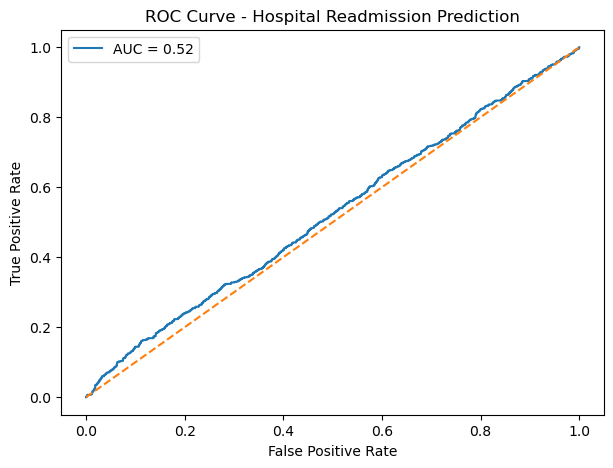

In [68]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Hospital Readmission Prediction"
)

plt.legend()

plt.show()


Confusion Matrix:
[[5248   17]
 [ 730    5]]


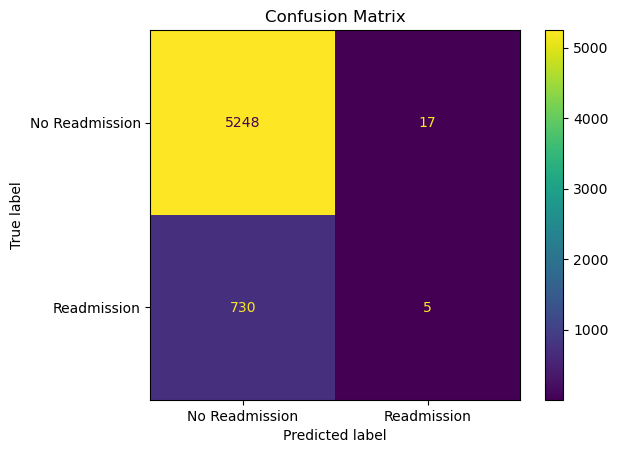

In [69]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Readmission", "Readmission"]
).plot()

plt.title("Confusion Matrix")

plt.show()

In [70]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Readmission",
            "Readmission"
        ]
    )
)


Classification Report:
                precision    recall  f1-score   support

No Readmission       0.88      1.00      0.93      5265
   Readmission       0.23      0.01      0.01       735

      accuracy                           0.88      6000
     macro avg       0.55      0.50      0.47      6000
  weighted avg       0.80      0.88      0.82      6000



In [71]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

print("\nFalse Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
print("True Negatives:", tn)


False Positives: 17
False Negatives: 730
True Positives: 5
True Negatives: 5248


## Clinical Interpretation

### False Negative (FN)
- Model predicts **Low Risk**
- Patient actually gets **readmitted within 30 days**
- **Clinical Cost:** High, because the patient may not receive additional monitoring, follow-up, or preventive care.

### False Positive (FP)
- Model predicts **High Risk**
- Patient actually **does not get readmitted**
- **Clinical Cost:** Unnecessary follow-up, monitoring, tests, and hospital resources.

### Conclusion
In hospital readmission prediction, **False Negatives can be more costly than False Positives**, because missing a high-risk patient can negatively affect patient care.